In [1]:
import sys
sys.path.append('../')
from src.data_loader import load_insurance_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Load the data
df = load_insurance_data()

# Data Profile
print(df.info())
print(df.describe())

# Check for missing values
missing_summary = df.isnull().sum()[df.isnull().sum() > 0]
print("Missing values per column:\n", missing_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  

In [3]:
# Portfolio metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Overall Portfolio Loss Ratio: {overall_loss_ratio:.2%}")

Overall Portfolio Loss Ratio: 52.82%


In [4]:
# By Province
province_risk = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()
province_risk['LossRatio'] = province_risk['TotalClaims'] / province_risk['TotalPremium']
print(province_risk.sort_values(by='LossRatio', ascending=False))

# By Gender
gender_risk = df.groupby('Gender')[['TotalClaims', 'TotalPremium']].sum()
gender_risk['LossRatio'] = gender_risk['TotalClaims'] / gender_risk['TotalPremium']
print(gender_risk)

             TotalClaims  TotalPremium  LossRatio
Province                                         
Somali         1826593.0       2984984   0.611927
Oromia         3261061.0       6069663   0.537272
Tigray         1047136.0       1990692   0.526016
Addis Ababa    4653210.0       8907374   0.522400
Amhara         2353885.0       4928566   0.477600
        TotalClaims  TotalPremium  LossRatio
Gender                                      
Female    6763030.0      12791141   0.528728
Male      6378855.0      12090138   0.527608


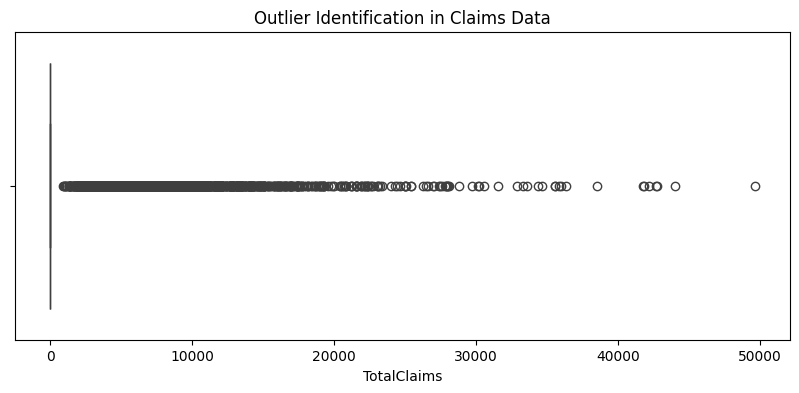

In [5]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalClaims'])
plt.title('Outlier Identification in Claims Data')
plt.show()

In [7]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'LossRatio', 'Margin']


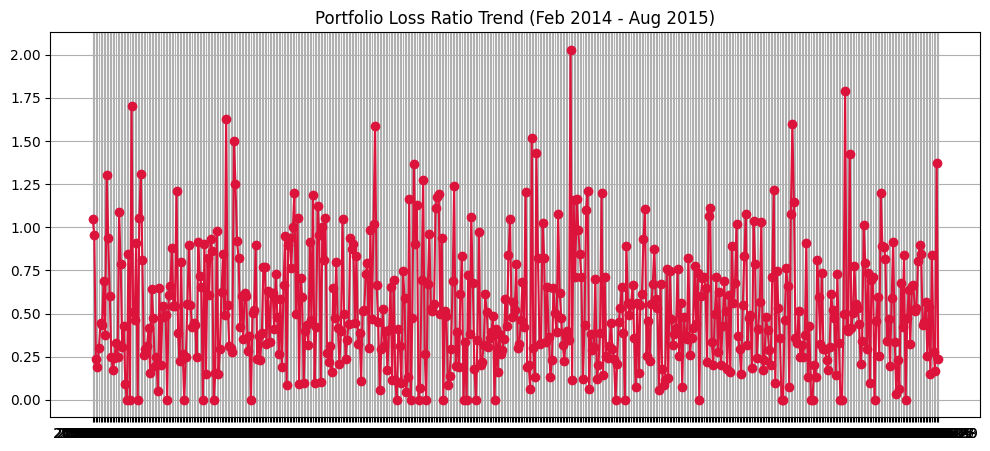

In [8]:
temporal_trend = df.groupby('TransactionDate')[['TotalClaims', 'TotalPremium']].sum()
temporal_trend['LossRatio'] = temporal_trend['TotalClaims'] / temporal_trend['TotalPremium']

plt.figure(figsize=(12, 5))
plt.plot(temporal_trend.index, temporal_trend['LossRatio'], marker='o', color='crimson')
plt.title('Portfolio Loss Ratio Trend (Feb 2014 - Aug 2015)')
plt.grid(True)
plt.show()